In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization, Activation, GlobalAveragePooling2D, Dense, Reshape, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import UpSampling2D

In [ ]:
import os
import shutil

BASE_PATH = "/content"
# Create fresh directory structure
os.makedirs(os.path.join(BASE_PATH, "real"), exist_ok=True)

print("Fresh directory structure created ")

Fresh directory structure created 


In [ ]:
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/Real.zip" /content/

In [ ]:
!rm -rf /content/real
!mkdir -p /content/real/Real
!unzip -q -j Real.zip -d /content/real/Real

In [ ]:
DATASET_PATH = "/content/real"

Setting Parameters

In [ ]:
IMG_SIZE = 224 # Images will be resized automatically
BATCH_SIZE = 16

Creating Image Data Generators for training and validation

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255, # Bring pixel values between 0 and 1
    validation_split=0.2 # Use 20% data for validation
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='input',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='input',
    subset='validation'
)

Found 13332 images belonging to 1 classes.
Found 3333 images belonging to 1 classes.


DenseNet-121 Encoder

In [ ]:
input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

encoder = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=input_img
)
encoder_output = encoder.output  # Output Shape: (7, 7, 1024)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# -------- Bottleneck --------

x = GlobalAveragePooling2D()(encoder_output)  # (1024)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)

latent = Dense(32, activation='relu', name="latent_vector")(x)

Decoder

In [ ]:
# -------- Decoder Initial Expansion --------

x = Dense(7 * 7 * 256, activation='relu')(latent)
x = Reshape((7, 7, 256))(x)
# -------- Decoder Upsampling --------

def up_block(x, filters):
    x = UpSampling2D((2,2))(x)
    x = Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    return x

x = up_block(x, 256)   # 14x14
x = up_block(x, 128)   # 28x28
x = up_block(x, 64)    # 56x56
x = up_block(x, 32)    # 112x112
x = up_block(x, 16)    # 224x224

decoded = Conv2D(3, (3,3), padding='same', activation='sigmoid')(x)

Compiling AutoEncoder

In [ ]:
autoencoder = Model(
    inputs=input_img,
    outputs=decoded
)
# PHASE 1
encoder.trainable=False
autoencoder.compile(
    optimizer=Adam(1e-4),
    loss=["mae"]
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,707,523 (33.22 MB)

 Trainable params: 1,668,515 (6.36 MB)

 Non-trainable params: 7,039,008 (26.85 MB)

Train AutoEncoder

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,            # epochs to wait after plateau
    restore_best_weights=True,
    mode='min',
    verbose=1
)

In [ ]:
history = autoencoder.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 186s 167ms/step - loss: 0.2272 - val_loss: 0.2111
Epoch 2/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.2036 - val_loss: 0.2042
Epoch 3/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1969 - val_loss: 0.2001
Epoch 4/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1929 - val_loss: 0.1995
Epoch 5/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 96s 116ms/step - loss: 0.1900 - val_loss: 0.1980
Epoch 6/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 96s 116ms/step - loss: 0.1876 - val_loss: 0.1960
Epoch 7/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1859 - val_loss: 0.1956
Epoch 8/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1840 - val_loss: 0.1952
Epoch 9/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1826 - val_loss: 0.1948
Epoch 10/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 98s 117ms/step - loss: 0.1817 - val_loss: 0.1966
Epoch 11/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 0.1800 - val_loss: 0.1960
Epoch 12/20
834/83

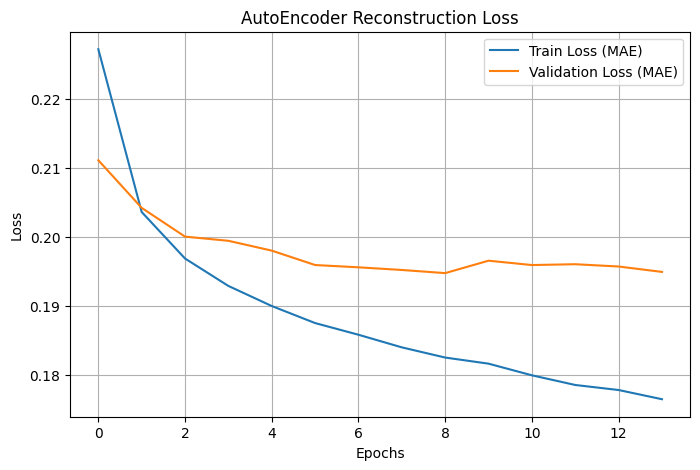

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Train Loss (MAE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MAE)')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('AutoEncoder Reconstruction Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
MODEL_SAVE_PATH = (
    "/content/drive/My Drive/Major Project/Base Models/"
    "densenet121_ae_real.keras"
)

autoencoder.save(MODEL_SAVE_PATH)

Load model and test

In [ ]:
from tensorflow.keras.models import load_model

MODEL_PATH = (
    "/content/drive/My Drive/Major Project/Base Models/"
    "densenet121_ae_real.keras"
)

autoencoder = load_model(MODEL_PATH)

In [ ]:
import os
import shutil

BASE_PATH = "/content"
# Create fresh directory structure
os.makedirs(os.path.join(BASE_PATH, "Datasets"), exist_ok=True)

print("Fresh directory structure created ")

Fresh directory structure created 


In [ ]:
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/AI.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/CGI.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/Edited.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/Real.zip" /content/

In [ ]:
!rm -rf /content/Datasets
!mkdir -p /content/Datasets/AI
!mkdir -p /content/Datasets/CGI
!mkdir -p /content/Datasets/Edited
!mkdir -p /content/Datasets/Real

!unzip -q -j AI.zip -d /content/Datasets/AI
!unzip -q -j CGI.zip -d /content/Datasets/CGI
!unzip -q -j Edited.zip -d /content/Datasets/Edited
!unzip -q -j Real.zip -d /content/Datasets/Real

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

BASE_PATH = "/content/Datasets"

CLASS_FOLDERS = {
    "Edited": os.path.join(BASE_PATH, "Edited"),
    "AI": os.path.join(BASE_PATH, "AI"),
    "CGI": os.path.join(BASE_PATH, "CGI"),
    "Real": os.path.join(BASE_PATH, "Real"),
}


In [ ]:
IMG_SIZE = 224  # or 256 – must match training

def load_and_preprocess(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

In [ ]:
def sample_images(folder, num_samples=500):
    all_images = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    return random.sample(all_images, min(num_samples, len(all_images)))

In [ ]:
def compute_mae(model, image_paths):
    errors = []

    for path in image_paths:
        img = load_and_preprocess(path)
        img = tf.expand_dims(img, axis=0)

        recon = model.predict(img, verbose=0)

        mae = tf.reduce_mean(tf.abs(img - recon))
        errors.append(mae.numpy())

    return np.array(errors)

In [ ]:
NUM_SAMPLES = 1000  # fraction, not full dataset

results = {}

for class_name, folder in CLASS_FOLDERS.items():
    sampled_imgs = sample_images(folder, NUM_SAMPLES)
    errors = compute_mae(autoencoder, sampled_imgs)
    results[class_name] = errors

    print(
        f"{class_name}: "
        f"Mean MAE = {errors.mean():.5f}, "
        f"Std = {errors.std():.5f}"
    )

Edited: Mean MAE = 0.19702, Std = 0.06246
AI: Mean MAE = 0.21693, Std = 0.07109
CGI: Mean MAE = 0.19368, Std = 0.06993
Real: Mean MAE = 0.17651, Std = 0.04525


Plotting Reconstructions MAEs

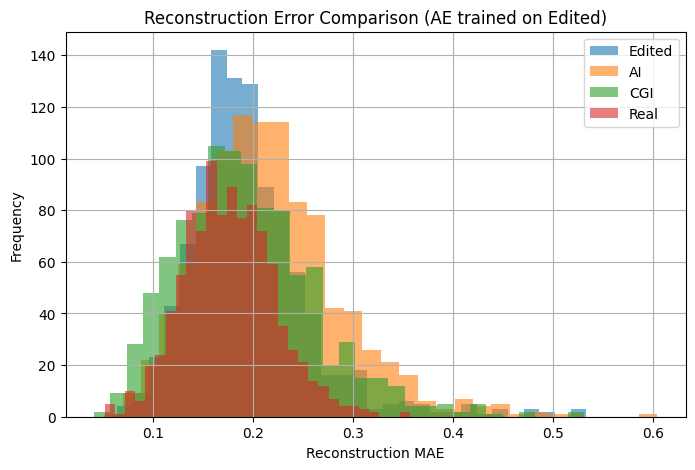

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for class_name, errors in results.items():
    plt.hist(errors, bins=30, alpha=0.6, label=class_name)

plt.xlabel("Reconstruction MAE")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Comparison (AE trained on Edited)")
plt.legend()
plt.grid(True)
plt.show()


Calculating mean error and standard deviation for edited class (5000 samples)

In [ ]:
IMG_SIZE = 224
N_SAMPLES = 5000
BATCH_SIZE = 32   # increase if GPU memory allows

In [ ]:
import os
import cv2
import random
import numpy as np
import tensorflow as tf

def evaluate_edited_image_level_batched(folder_path):
    files = os.listdir(folder_path)
    files = random.sample(files, min(N_SAMPLES, len(files)))

    scores = []

    batch_imgs = []

    for idx, f in enumerate(files):
        img_path = os.path.join(folder_path, f)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype("float32") / 255.0

        batch_imgs.append(img)

        # When batch is full → predict
        if len(batch_imgs) == BATCH_SIZE or idx == len(files) - 1:
            batch_imgs = np.array(batch_imgs)

            recon = autoencoder.predict(
                batch_imgs,
                batch_size=BATCH_SIZE,
                verbose=0
            )

            batch_mae = np.mean(
                np.abs(batch_imgs - recon),
                axis=(1, 2, 3)
            )

            scores.extend(batch_mae.tolist())
            batch_imgs = []

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx+1}/{len(files)}")

    scores = np.array(scores)
    return np.mean(scores), np.std(scores)

In [ ]:
edited_mean, edited_std = evaluate_edited_image_level_batched(
    "/content/edited/Edited"
)

print("Edited class (5000 samples, image-level):")
print(f"Mean MAE = {edited_mean:.5f}")
print(f"Std  MAE = {edited_std:.5f}")


Processed 500/5000
Processed 1000/5000
Processed 1500/5000
Processed 2000/5000
Processed 2500/5000
Processed 3000/5000
Processed 3500/5000
Processed 4000/5000
Processed 4500/5000
Processed 5000/5000
Edited class (5000 samples, image-level):
Mean MAE = 0.18000
Std  MAE = 0.06883
